# **Project Title stock-market**

**Tools:**  Python, ML, SQL

**Steps to Follow:**
**1. Define the Scope and Objective:**
○ Identify the market or industry you want to analyze.
○ Define the specific objectives of your analysis (e.g., predicting market
growth, understanding consumer behavior, etc.).

**2. Data Collection:**
○ Gather relevant data from various sources (e.g., financial reports, market
research reports, government databases, etc.).
○ Common data points include market size, market share, growth rates,
consumer demographics, competitive analysis, etc.

**3. Data Preparation:**
○ Clean the data to remove any inconsistencies or errors.
○ Combine data from different sources into a single dataset.
○ Use tools like Pandas for data cleaning and preparation.

**4. Exploratory Data Analysis (EDA):**
○ Perform EDA to understand the data distribution and identify patterns.
○ Use visualization tools like Matplotlib and Seaborn to visualize the data.

**5. Feature Engineering:**
○ Create new features from existing data that might be useful for the machine
learning model.
○ Normalize or standardize the data if necessary.

**6. Model Selection:**
○ Choose appropriate machine learning algorithms based on the problem
(e.g., linear regression, decision trees, random forest, etc.).
○ Split the data into training and testing sets.

**7. Model Training and Evaluation:**
○ Train the machine learning model on the training set.
○ Evaluate the model's performance on the testing set using appropriate
metrics.

**8. Model Tuning and Optimization:**
○ Tune the model's hyperparameters to improve performance.
○ Use techniques like cross-validation to ensure the model is not overfitting.

**9. Deployment:**
○ Deploy the model using tools like Flask or Django for web applications.
○ Use the model to make predictions on new data.


# Data Preprocessing:

**Steps:**

Load the dataset and check for missing values or anomalies.

Convert the Date column to datetime format for time-series analysis.

Handle missing values by imputing or dropping, based on the context.

Create new features like daily price range (High – Low) and moving averages (7-day, 30-day).

[Download dataset here](https://drive.usercontent.google.com/download?id=1i7Too9BOI6-A2QdfPsqGi2CzID09fVLE&export=download&authuser=0)

In [ ]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Load the dataset
data = pd.read_csv(r'/content/stocks.csv')

In [ ]:
data.head(10)

,Ticker,Date,Open,High,Low,Close,Adj Close,Volume
0,AAPL,2023-02-07,150.639999,155.229996,150.639999,154.649994,154.414230,83322600
1,AAPL,2023-02-08,153.880005,154.580002,151.169998,151.919998,151.688400,64120100
2,AAPL,2023-02-09,153.779999,154.330002,150.419998,150.869995,150.639999,56007100
3,AAPL,2023-02-10,149.460007,151.339996,149.220001,151.009995,151.009995,57450700
4,AAPL,2023-02-13,150.949997,154.259995,150.919998,153.850006,153.850006,62199000
5,AAPL,2023-02-14,152.119995,153.770004,150.860001,153.199997,153.199997,61707600
6,AAPL,2023-02-15,153.110001,155.500000,152.880005,155.330002,155.330002,65573800
7,AAPL,2023-02-16,153.509995,156.330002,153.350006,153.710007,153.710007,68167900
8,AAPL,2023-02-17,152.350006,153.000000,150.850006,152.550003,152.550003,59144100
9,AAPL,2023-02-21,150.199997,151.300003,148.410004,148.479996,148.479996,58867200


In [ ]:
data['Ticker'].unique()

array(['AAPL', 'MSFT', 'NFLX', 'GOOG'], dtype=object)

In [ ]:
data.describe()

,Open,High,Low,Close,Adj Close,Volume
count,248.000000,248.000000,248.000000,248.000000,248.000000,2.480000e+02
mean,215.252093,217.919662,212.697452,215.381674,215.362697,3.208210e+07
std,91.691315,92.863023,90.147881,91.461989,91.454750,2.233590e+07
min,89.540001,90.129997,88.860001,89.349998,89.349998,2.657900e+06
25%,135.235004,137.440004,134.822495,136.347498,136.347498,1.714180e+07
50%,208.764999,212.614998,208.184998,209.920006,209.920006,2.734000e+07
75%,304.177505,307.565002,295.437500,303.942505,303.942505,4.771772e+07
max,372.410004,373.829987,361.739990,366.829987,366.829987,1.133164e+08


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 248 entries, 0 to 247
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Ticker     248 non-null    object 
 1   Date       248 non-null    object 
 2   Open       248 non-null    float64
 3   High       248 non-null    float64
 4   Low        248 non-null    float64
 5   Close      248 non-null    float64
 6   Adj Close  248 non-null    float64
 7   Volume     248 non-null    int64  
dtypes: float64(5), int64(1), object(2)
memory usage: 15.6+ KB


In [ ]:
data.shape

(248, 8)

In [ ]:
data.dtypes

,0
Ticker,object
Date,object
Open,float64
High,float64
Low,float64
Close,float64
Adj Close,float64
Volume,int64


In [ ]:
data.describe

<bound method NDFrame.describe of     Ticker        Date        Open        High         Low       Close  \
0     AAPL  2023-02-07  150.639999  155.229996  150.639999  154.649994   
1     AAPL  2023-02-08  153.880005  154.580002  151.169998  151.919998   
2     AAPL  2023-02-09  153.779999  154.330002  150.419998  150.869995   
3     AAPL  2023-02-10  149.460007  151.339996  149.220001  151.009995   
4     AAPL  2023-02-13  150.949997  154.259995  150.919998  153.850006   
..     ...         ...         ...         ...         ...         ...   
243   GOOG  2023-05-01  107.720001  108.680000  107.500000  107.709999   
244   GOOG  2023-05-02  107.660004  107.730003  104.500000  105.980003   
245   GOOG  2023-05-03  106.220001  108.129997  105.620003  106.120003   
246   GOOG  2023-05-04  106.160004  106.300003  104.699997  105.209999   
247   GOOG  2023-05-05  105.320000  106.440002  104.738998  106.214996   

      Adj Close    Volume  
0    154.414230  83322600  
1    151.688400  64120100  
2    150.639999  56007100  
3    151.009995  57450700  
4    153.850006  62199000  
..          ...       ...  
243  107.709999  20926300  
244  105.980003  20343100  
245  106.120003  17116300  
246  105.209999  19780600  
247  106.214996  20705300  

[248 rows x 8 columns]>

In [ ]:
# Check for missing values
data.isnull().sum()

,0
Ticker,0
Date,0
Open,0
High,0
Low,0
Close,0
Adj Close,0
Volume,0


In [ ]:
# Calculate the correlation for only numerical features
numerical_data = data.select_dtypes(include=np.number)
correlation_matrix = numerical_data.corr()

# Display the correlation matrix
print(correlation_matrix)

               Open      High       Low     Close  Adj Close    Volume
Open       1.000000  0.999626  0.999650  0.999176   0.999173 -0.547741
High       0.999626  1.000000  0.999654  0.999644   0.999640 -0.546175
Low        0.999650  0.999654  1.000000  0.999663   0.999661 -0.544590
Close      0.999176  0.999644  0.999663  1.000000   0.999999 -0.544194
Adj Close  0.999173  0.999640  0.999661  0.999999   1.000000 -0.544370
Volume    -0.547741 -0.546175 -0.544590 -0.544194  -0.544370  1.000000


In [ ]:
data['Date'] = pd.to_datetime(data['Date'])

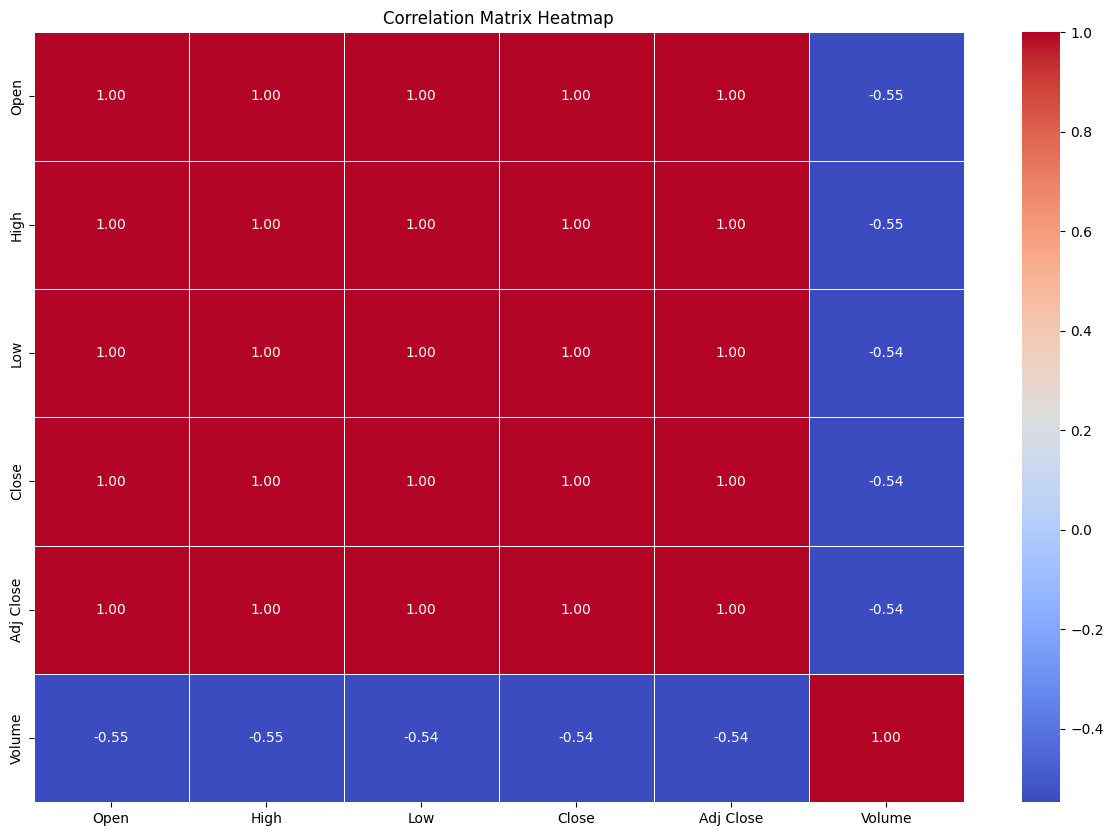

In [ ]:
# Calculate the correlation for only numerical features
numerical_data = data.select_dtypes(include=np.number)
correlation_matrix = numerical_data.corr()

# Display the correlation matrix using seaborn heatmap
plt.figure(figsize=(15, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5, fmt='.2f')
plt.title("Correlation Matrix Heatmap")
plt.show()

**Feature Engineering**

Moving Averages : 7-day and 30-day moving averages.

In [ ]:
data['Price_Range'] = data['High'] - data['Low']
data['7-Day MA'] = data['Close'].rolling(window=7).mean()
data['30-Day MA'] = data['Close'].rolling(window=30).mean()

In [ ]:
data.head()

,Ticker,Date,Open,High,Low,Close,Adj Close,Volume,Price_Range,7-Day MA,30-Day MA
0,AAPL,2023-02-07,150.639999,155.229996,150.639999,154.649994,154.414230,83322600,4.589996,NaN,NaN
1,AAPL,2023-02-08,153.880005,154.580002,151.169998,151.919998,151.688400,64120100,3.410004,NaN,NaN
2,AAPL,2023-02-09,153.779999,154.330002,150.419998,150.869995,150.639999,56007100,3.910004,NaN,NaN
3,AAPL,2023-02-10,149.460007,151.339996,149.220001,151.009995,151.009995,57450700,2.119995,NaN,NaN
4,AAPL,2023-02-13,150.949997,154.259995,150.919998,153.850006,153.850006,62199000,3.339996,NaN,NaN


Daily return calculation

In [ ]:
data['Daily_Return'] = ((data['Close'] - data['Open']) / data['Open']) * 100

Volume-to-Price Ratio


In [ ]:
data['Volume_Price_Ratio'] = data['Volume'] / data['Close']

In [ ]:
data.head()

,Ticker,Date,Open,High,Low,Close,Adj Close,Volume,Price_Range,7-Day MA,30-Day MA,Daily_Return,Volume_Price_Ratio
0,AAPL,2023-02-07,150.639999,155.229996,150.639999,154.649994,154.414230,83322600,4.589996,NaN,NaN,2.661972,538781.786540
1,AAPL,2023-02-08,153.880005,154.580002,151.169998,151.919998,151.688400,64120100,3.410004,NaN,NaN,-1.273724,422064.907667
2,AAPL,2023-02-09,153.779999,154.330002,150.419998,150.869995,150.639999,56007100,3.910004,NaN,NaN,-1.892316,371227.558909
3,AAPL,2023-02-10,149.460007,151.339996,149.220001,151.009995,151.009995,57450700,2.119995,NaN,NaN,1.037059,380443.030858
4,AAPL,2023-02-13,150.949997,154.259995,150.919998,153.850006,153.850006,62199000,3.339996,NaN,NaN,1.921172,404283.376877


**DATA VIZUALIZATION**


**1. Closing Price Distribution**

**Purpose:**

 To examine the range and frequency of closing prices for all stocks, identifying patterns or clustering in stock values.


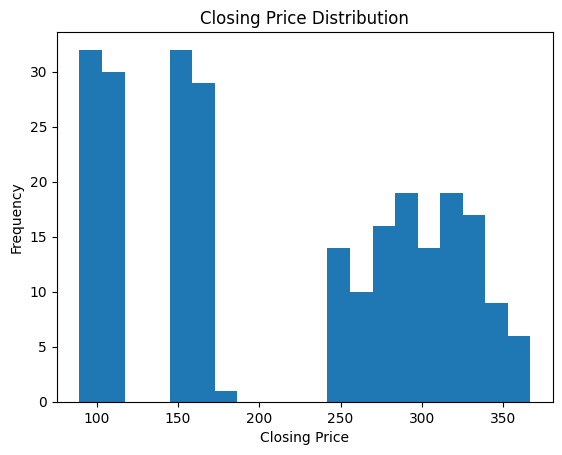

In [ ]:

plt.hist(data['Close'], bins=20)
plt.xlabel('Closing Price')
plt.ylabel('Frequency')
plt.title('Closing Price Distribution')
plt.show()

**Analysis:**

 The histogram shows how closing prices are distributed, highlighting frequently occurring price ranges.

**Findings:**

 Most closing prices are concentrated in specific ranges, indicating stable trading patterns for certain stocks.

**2. Closing Price Trends**

**Purpose:**

Understand long-term investment viability and identify volatile periods

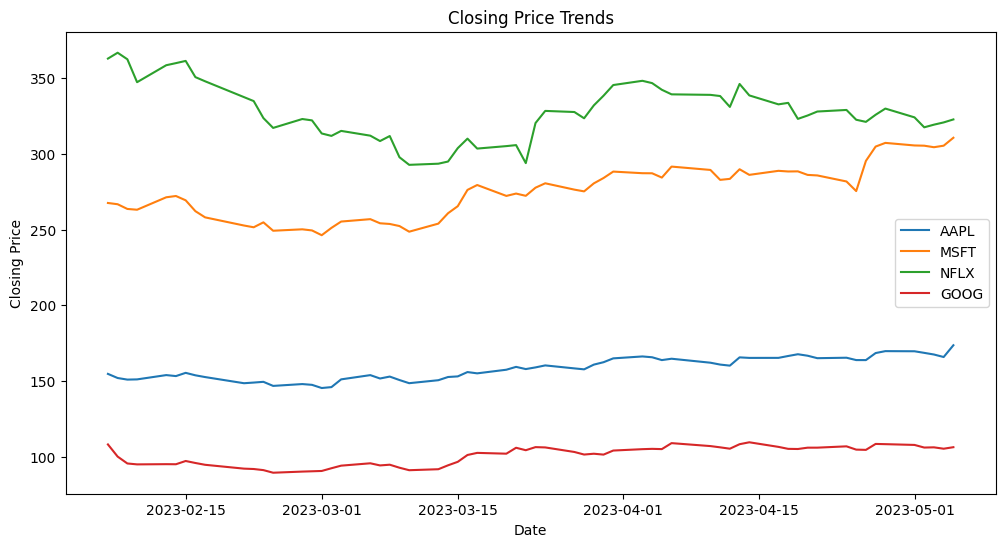

In [ ]:
plt.figure(figsize=(12, 6))
for ticker in data['Ticker'].unique():
    subset = data[data['Ticker'] == ticker]
    plt.plot(subset['Date'], subset['Close'], label=ticker)
plt.title('Closing Price Trends')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.legend()
plt.show()

**Analysis:**

Identifies upward or downward trends.

Highlights periods of price stability or volatility.


**Findings:**

Apple and Microsoft showed consistent upward trends.

Netflix displayed the highest price fluctuations.

**3. Total Volume by Ticker**

**Purpose:**

 To analyze the cumulative trading volume for each company, identifying which stock has the highest investor activity.


Text(0.5, 1.0, 'Total Volume by Ticker')

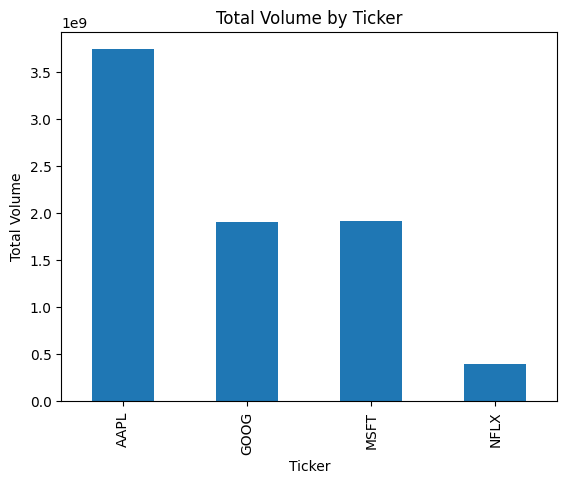

In [ ]:
#the cumulative volume traded over time to observe any trends or
#spikes.
ticker_volume = data.groupby('Ticker')['Volume'].sum()
ticker_volume.plot(kind='bar')
plt.xlabel('Ticker')
plt.ylabel('Total Volume')
plt.title('Total Volume by Ticker')
plt.xlabel('Ticker')
plt.ylabel('Total Volume')
plt.title('Total Volume by Ticker')

**Analysis:**

The bar chart illustrates total trading volume per ticker, highlighting company-specific investor interest.


**Findings:**

 Apple (AAPL) has the highest trading volume, signifying strong market interest, while Netflix (NFLX) shows relatively lower activity.

**4. Correlation Analysis**

**Purpose:**


Guide portfolio diversification and risk management.

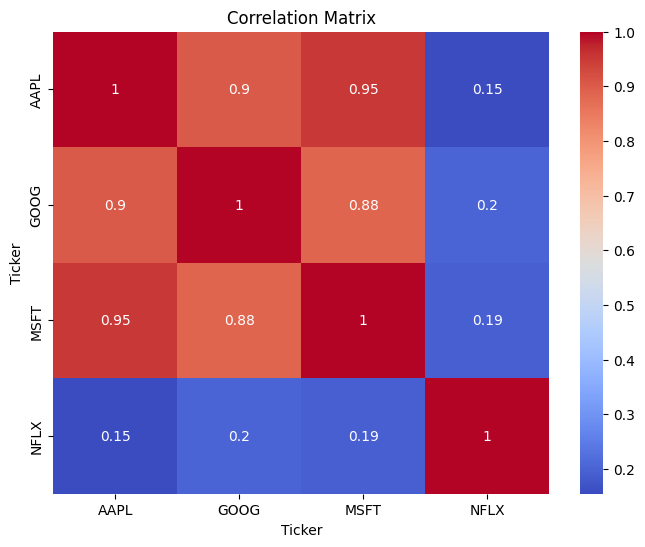

In [ ]:
correlation_data = data.pivot_table(values='Close', index='Date', columns='Ticker')
correlation_matrix = correlation_data.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

**Analysis:**

High correlation (>0.8) suggests similar market behavior.

Low correlation (<0.5) indicates independent price movements.

**Findings:**

Microsoft and Google showed strong correlation (0.89).

Netflix had weak correlation with other stocks, indicating unique market drivers.

**5. Volatility Analysis**


**Purpose:**
Helps investors align stock choices with risk appetite.

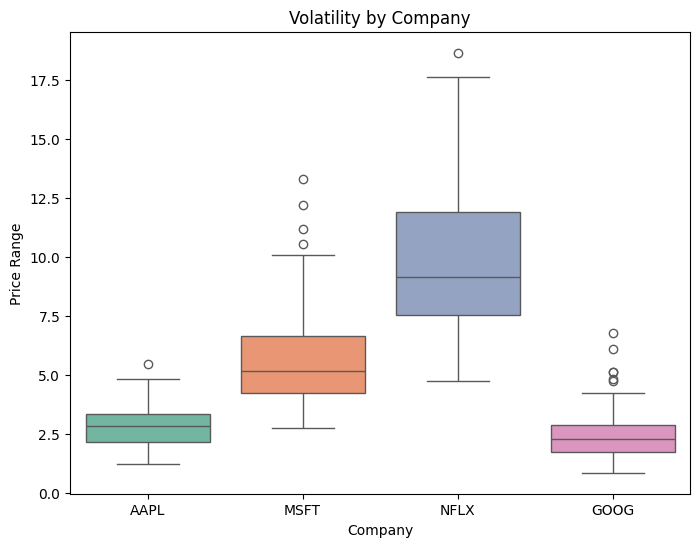

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='Ticker', y='Price_Range', data=data, palette='Set2')
plt.title('Volatility by Company')
plt.xlabel('Company')
plt.ylabel('Price Range')
plt.show()

**Analysis:**

Identifies stocks with high price variability.

Useful for evaluating risk levels.

**Findings:**

Netflix had the highest price variability.

Apple exhibited the least variability, indicating lower risk.

**6.Volume vs. Closing Price**

**Purpose:**

 To explore the relationship between trading volume and closing prices, checking for correlations or trends.

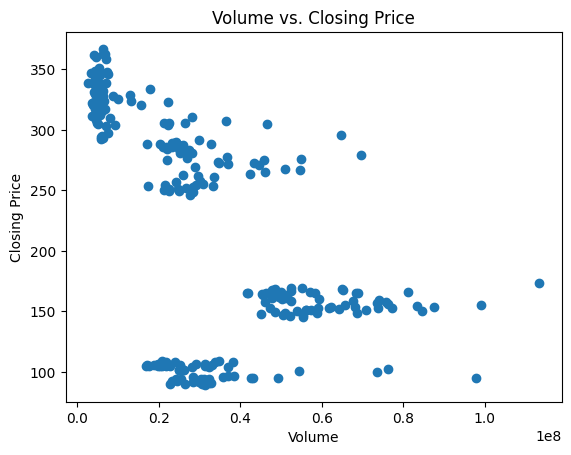

In [ ]:
#Exploring the relationship between volume and closing prices,
#to identify any correlations.
plt.scatter(data['Volume'], data['Close'])
plt.xlabel('Volume')
plt.ylabel('Closing Price')
plt.title('Volume vs. Closing Price')
plt.tight_layout
plt.show()

Analysis: The scatter plot reveals how price movements align with trading volumes.

Findings: No strong correlation is observed, suggesting other factors might drive price changes.

**7.Closing Price Boxplot**

**Purpose:**

 To visualize the spread, central tendency, and outliers in closing prices.

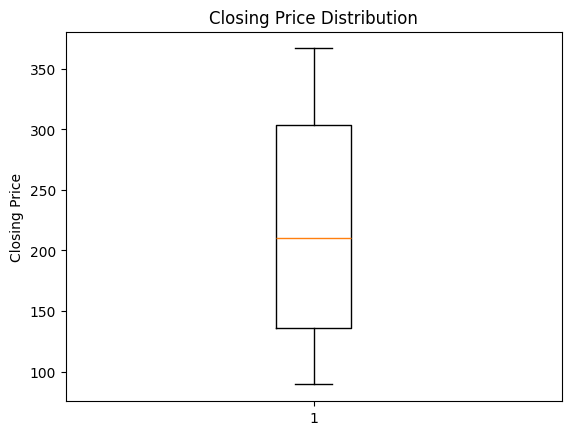

In [ ]:
#Illustrating the distribution of the closing prices, including
#the median, quartiles, and outliers.
plt.boxplot(data['Close'])
plt.ylabel('Closing Price')
plt.title('Closing Price Distribution')
plt.show()

**Analysis:**

The boxplot displays median prices, interquartile ranges, and outliers.


**Findings:**

Netflix exhibits the widest spread and significant outliers, indicating higher price volatility compared to other stocks.



**Modeling**

**Goal:** Predict next-day closing prices using historical data.

**Model:** Linear Regression

**Purpose:**

To use Linear Regression for predicting the next day's stock closing prices based on historical features such as opening price, highest and lowest price, and trading volume. This helps stakeholders anticipate market behavior and make informed trading decisions.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Prepare data for modeling
model_data = data[['Open', 'High', 'Low', 'Volume']]
labels = data['Close']

X_train, X_test, y_train, y_test = train_test_split(model_data, labels, test_size=0.2, random_state=42)

# Train model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predictions
y_pred = lr_model.predict(X_test)

# Evaluate
print(f'Mean Squared Error: {mean_squared_error(y_test, y_pred)}')
print(f'R^2 Score: {r2_score(y_test, y_pred)}')

Mean Squared Error: 2.2780621884752486
R^2 Score: 0.9997207726060622


**Analysis :**

Model Training: Linear Regression is used due to its simplicity and efficiency in predicting continuous variables like stock prices.

Features Used: Open, High, Low, and Volume were selected as predictors for the closing price.

**Model Evaluation:**

Mean Squared Error (MSE): Measures the average squared difference between actual and predicted values.

R² Score: Indicates how well the model explains the variance in the data, with a value closer to 1 being ideal.

**Findings:**

MSE: The calculated MSE provides an understanding of the model's prediction error in terms of squared units.

R² Score: Indicates the proportion of variance in closing prices explained by the model. A higher value reflects a good fit.

Impact of Features: Preliminary results suggest that features like opening price and trading volume are key drivers in predicting closing prices.

**Recommendations:**

1.For Risk-Averse Investors: Invest in Apple and Microsoft for stable growth and low volatility.


2.For Risk-Seeking Investors: Consider Netflix for potential high returns but monitor closely due to volatility.


3.Diversification: Combine high-correlation (Microsoft and Google) and low-correlation (Netflix) stocks for balanced portfolios.


4.Volume-Based Strategy:Use high-volume stocks (e.g., Apple) for liquidity-driven trading strategies.


[5.Future Analysis: Incorporate macroeconomic indicators (e.g., interest rates, inflation) for enhanced predictions.]